To collect the data, run `make profile_fp16_radix_sort`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["v", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

dtype = "fp16"

In [2]:
PREFIX_PATH = "../../.."

tiles = [32, 64, 128]
radixsort_df = pd.concat(map(pd.read_csv, glob(join('../../../', f"*sort*_fp16.csv"))))


df_baseline = pd.read_csv(f"{PREFIX_PATH}/bench_results_sort_{dtype}.csv")
df_baseline["S"] = "PyTorch"


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.read_csv(f"{PREFIX_PATH}/bench_results_radix_sort_{tile}_{dtype}.csv")
    df_tmp["S"] = f"s={tile}"
    df_tiled = pd.concat([df_tiled, df_tmp])


df = pd.concat([df_baseline, df_tiled])

df['mem_bytes'] = (df['size'] * 2)  + df['outputsize'] * 2 + df['outputsize'] * 2
df['bandwidth_gbps'] = (df['mem_bytes']) / (df['time_us']*1000) #GB/s
df['time_ms'] = df['time_us'] / 1000

/tmp/ipykernel_1579074/1837231297.py:10: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.lineplot(x='size', y='bandwidth_gbps', palette=palette, data=df, **_SNS_PARAMS)


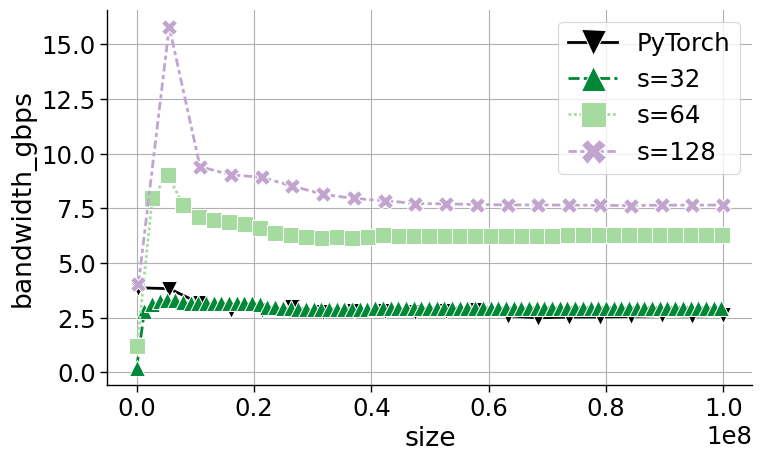

In [ ]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_gbps', palette=palette, data=df, **_SNS_PARAMS)

sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()


/tmp/ipykernel_1579074/2181349453.py:11: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.lineplot(x='size', y='time_ms', data=df, palette=palette, **_SNS_PARAMS)


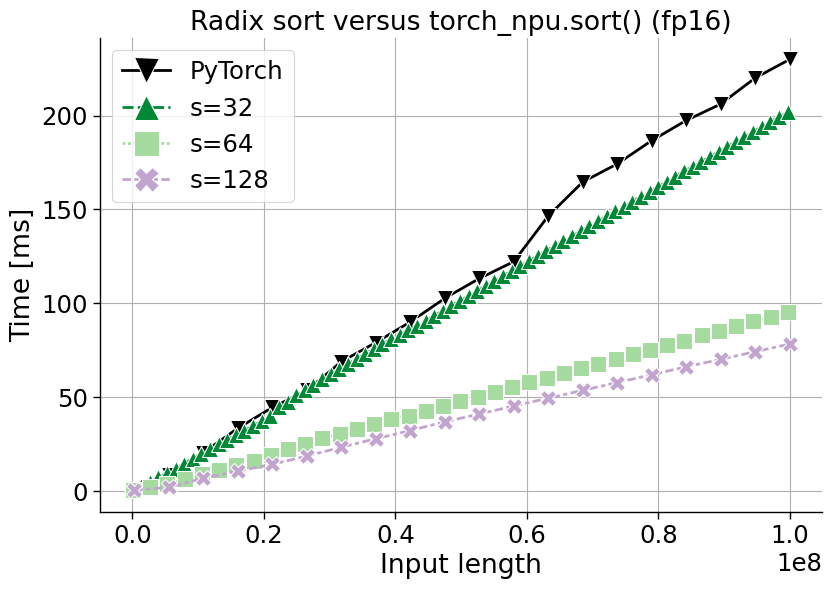

<Figure size 870x627 with 0 Axes>

In [ ]:
palette = [### Colorbrewer colors
"black",
"#008837",
"#a6dba0",
"#c2a5cf",
"#7b3294",]

radixsort_df['time_ms'] = radixsort_df['time_us'] / 1000

ax = sns.lineplot(x='size', y='time_ms', data=df, palette=palette, **_SNS_PARAMS)

ax.set_title(f"Radix sort versus torch_npu.sort() ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Time [ms]")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/sort_time_{dtype}.png")
plt.show()
plt.clf()